# Plot model output with uncertainty

In [3]:
from scipy.io import loadmat
import numpy as np
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd

In [69]:
mat_error_path = '/Users/mzahn/data/SSH/model_ssh/greenland_normalized_uncertainty_structure_and_fingerprint.mat'

data = loadmat(mat_error_path)

print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'bed', 'icethickness', 'issmgmsl_rsl', 'latv', 'lonv', 'oceanlevelset', 'rsl', 'sealevel'])


In [71]:
lat = np.squeeze(data['latv'])
lon = np.squeeze(data['lonv'])

bed = np.squeeze(data['bed'])
rsl = np.squeeze(data['rsl'])
asl = np.squeeze(data['sealevel'])
mask = np.squeeze(data['oceanlevelset'])
gmsl = np.squeeze(data['issmgmsl_rsl']) # The globally averaged relative sea level contribution from the ISSM forcing

In [73]:
print("lat:", lat.shape)
print("lon:", lon.shape)
print("bed:", bed.shape)
print("rsl:", rsl.shape)
print("asl:", asl.shape)
print("mask:", mask.shape)
print("gmsl:", gmsl.shape)

lat: (90698,)
lon: (90698,)
bed: (90698,)
rsl: (90698,)
asl: (90698,)
mask: (90698,)
gmsl: ()


In [284]:
# ---------------------------
# Load MATLAB file
mat_path = '/Users/mzahn/data/SSH/model_ssh/greenland_normalized_uncertainty_structure_and_fingerprint.mat'
data = loadmat(mat_path)

# ---------------------------
# Extract & clean variables
lat = np.squeeze(data["latv"])
lon = np.squeeze(data["lonv"])
asl_error = np.squeeze(data["sealevel"])
land_mask = np.squeeze(data["oceanlevelset"])
icethickness = np.squeeze(data["icethickness"])

# ---------------------------
# Create xarray Dataset
ssh_model_ds = xr.Dataset(
    data_vars={
        "asl_error": (("point"), asl_error),
        "land_mask": (("point"), land_mask),
        "icethickness": (("point"), icethickness)
    },
    coords={
        "point": np.arange(len(lat)),
        "lat": ("point", lat),
        "lon": ("point", lon),
    },
    attrs={
        "grid_type": "unstructured",
        "description": "Greenland normalized sea level uncertainty fields (1992–2023)"
    }
)

In [96]:
error = ssh_model_ds.asl_error

In [286]:
# select cutout of Labrador Sea
ssh_model_greenland = ssh_model_ds.where(
    (ssh_model_ds.lat > 50) & (ssh_model_ds.lat < 65) &
    (ssh_model_ds.lon > -70) & (ssh_model_ds.lon < -40),
    drop=True)

In [100]:
ssh_model_greenland

<xarray.Dataset> Size: 332kB
Dimensions:    (point: 8289)
Coordinates:
  * point      (point) int64 66kB 37256 37257 37258 37259 ... 85673 85714 85721
    lat        (point) float64 66kB 62.65 63.77 57.08 ... 60.96 60.66 63.79
    lon        (point) float64 66kB -50.31 -48.74 -42.11 ... -43.12 -41.08
Data variables:
    asl_error  (point) float64 66kB 0.006795 0.01064 ... 0.005311 0.01144
    land_mask  (point) float64 66kB -0.7271 1.684e+03 ... 122.4 1.001e+03
Attributes:
    grid_type:    unstructured
    description:  Greenland normalized sea level uncertainty fields (1992–2023)

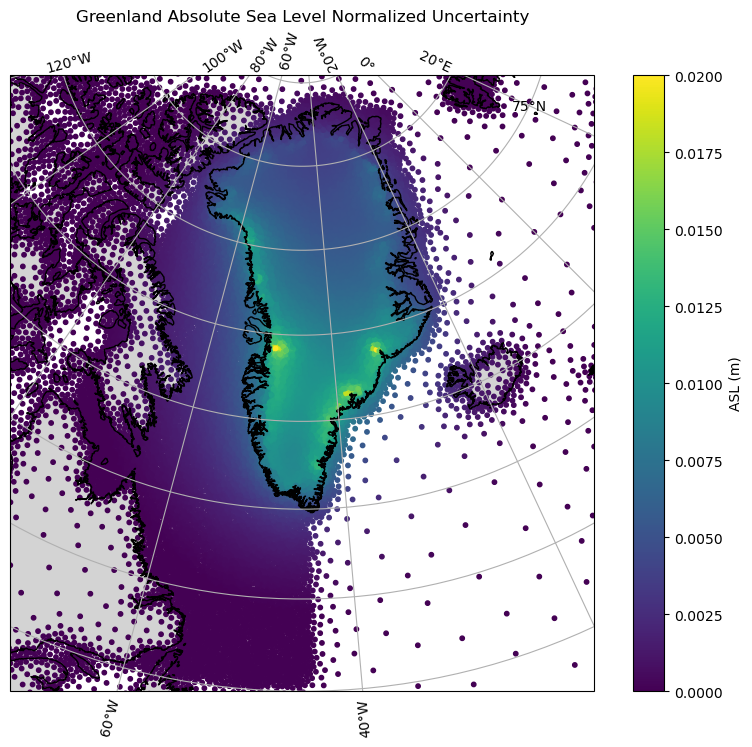

In [102]:
# plot

fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=-45))
ax.set_extent([-70, -20, 50, 85], crs=ccrs.PlateCarree())  # Greenland region

# Add features
ax.coastlines(resolution='10m')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.gridlines(draw_labels=True)

# Scatter plot of unstructured points
sc = ax.scatter(
    error.lon, error.lat,
    c=error.values,
    cmap='viridis',
    s=10, vmin=0, vmax=0.02,
    transform=ccrs.PlateCarree()
)

# Colorbar
cbar = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.05)
cbar.set_label("ASL (m)")

plt.title(f"Greenland Absolute Sea Level Normalized Uncertainty")
plt.show()

In [290]:
icethickness = ssh_model_ds.icethickness

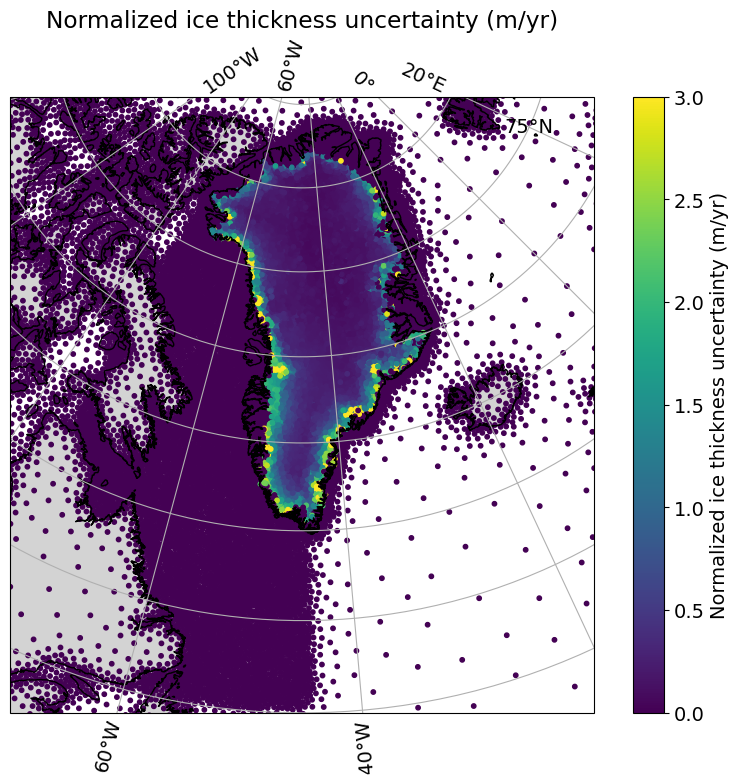

In [296]:
# plot

fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=-45))
ax.set_extent([-70, -20, 50, 85], crs=ccrs.PlateCarree())  # Greenland region

# Add features
ax.coastlines(resolution='10m')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.gridlines(draw_labels=True)

# Scatter plot of unstructured points
sc = ax.scatter(
    icethickness.lon, icethickness.lat,
    c=icethickness.values,
    cmap='viridis',
    s=10, vmin=0, vmax=3,
    transform=ccrs.PlateCarree()
)

# Colorbar
cbar = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.05)
cbar.set_label("Normalized ice thickness uncertainty (m/yr)")

plt.title(f"Normalized ice thickness uncertainty (m/yr)")
plt.show()

In [104]:
# mask out land points (Ocean has negative values)
ssh_model_lab_ocean = ssh_model_greenland.where(ssh_model_greenland.land_mask<0)

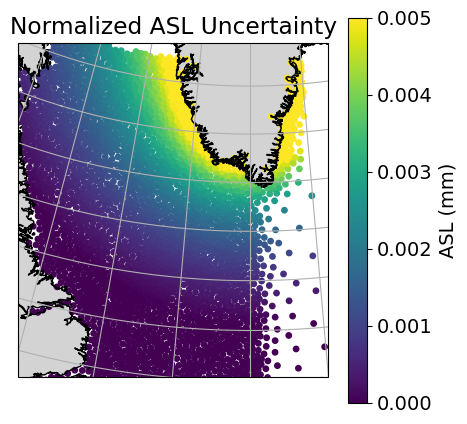

In [282]:
# plot

fig = plt.figure(figsize=(5, 5))
ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=-45))
# ax.set_extent([-70, -20, 50, 85], crs=ccrs.PlateCarree())  # Greenland region
ax.set_extent([-60, -40, 52, 65], crs=ccrs.PlateCarree())  # Greenland region

# Add features
ax.coastlines(resolution='10m')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.gridlines(draw_labels=False)

# Scatter plot of unstructured points
sc = ax.scatter(
    ssh_model_lab_ocean.lon, ssh_model_lab_ocean.lat,
    c=ssh_model_lab_ocean.asl_error.values,
    cmap='viridis',
    s=15, vmin=0, vmax=0.005,
    transform=ccrs.PlateCarree()
)

# Colorbar
cbar = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.05)
cbar.set_label("ASL (mm)")

plt.title(f"Normalized ASL Uncertainty")
plt.show()

In [110]:
ssh_model_lab_ocean.to_netcdf('/Users/mzahn/data/SSH/model_ssh/greenland_normalized_uncertainty.nc')

In [112]:
ssh_model_lab_ocean

<xarray.Dataset> Size: 332kB
Dimensions:    (point: 8289)
Coordinates:
  * point      (point) int64 66kB 37256 37257 37258 37259 ... 85673 85714 85721
    lat        (point) float64 66kB 62.65 63.77 57.08 ... 60.96 60.66 63.79
    lon        (point) float64 66kB -50.31 -48.74 -42.11 ... -43.12 -41.08
Data variables:
    asl_error  (point) float64 66kB 0.006795 nan 0.001077 ... 0.004649 nan nan
    land_mask  (point) float64 66kB -0.7271 nan -3.373e+03 ... nan nan
Attributes:
    grid_type:    unstructured
    description:  Greenland normalized sea level uncertainty fields (1992–2023)

## Pull out AR7W line from points

In [128]:
# open uncertainty netcdf
model_uncertainty_ds = xr.open_dataset('/Users/mzahn/data/SSH/model_ssh/greenland_normalized_uncertainty.nc')

In [130]:
import numpy as np
import xarray as xr
from pyproj import Geod
from scipy.interpolate import griddata

In [136]:
# -----------------------------
# 1. Define transect endpoints
# -----------------------------
lat1, lon1 = 54.0, -55.5
lat2, lon2 = 60.5, -48.0

geod = Geod(ellps="WGS84")

# total distance
_, _, total_dist = geod.inv(lon1, lat1, lon2, lat2)

spacing = 10_000  # 10 km
npts = int(total_dist // spacing) + 1

# intermediate geodesic points
pts = geod.npts(lon1, lat1, lon2, lat2, npts - 2)

lons = np.array([lon1] + [p[0] for p in pts] + [lon2])
lats = np.array([lat1] + [p[1] for p in pts] + [lat2])

# -----------------------------
# 2. Distance along transect
# -----------------------------
dist = np.zeros(len(lons))
for i in range(1, len(lons)):
    _, _, d = geod.inv(lons[i-1], lats[i-1], lons[i], lats[i])
    dist[i] = dist[i-1] + d

dist_km = dist / 1000

# -----------------------------
# 3. Prepare interpolation grid
# -----------------------------
points = np.column_stack([
    ssh_model_lab_ocean.lon.values,
    ssh_model_lab_ocean.lat.values
])

target = np.column_stack([lons, lats])

# -----------------------------
# 4. Interpolate each timestep
# -----------------------------
out = griddata(
    points,
    model_uncertainty_ds.asl_error.values,
    target,
    method="linear")

# -----------------------------
# 5. Convert to xarray
# -----------------------------
transect = xr.DataArray(
    out,
    dims=("distance_km"),
    coords=dict(
        distance_km=dist_km,
        lat=("distance_km", lats),
        lon=("distance_km", lons),
    ),
    name="asl_error_transect"
)

1. multiply GMSL time series by 360 to convert that from mm of GMSL to Gt of ice mass change. 

2. 10-20% of that time series would be a reasonable assumption for Greenland mass change uncertainty 

3. Extract an uncertainty transect from the attached dataset, which is normalized for 1-Gt of ice mass change. 

4. multiply 3 (i.e., spatial pattern) by 2 to produce spatiotemporal pattern of fingerprint uncertainty. 

In [166]:
# now multiply uncertainty by gmsl
gmsl_ds = xr.open_dataset("/Users/mzahn/data/SSH/model_ssh/model_gmsl.nc")

In [232]:
# multiply GMSL time series by 360 to convert that from mm of GMSL to Gt of ice mass change
gmsl_Gt = gmsl_ds.gmsl * 360

# 10-20% of that time series would be a reasonable assumption for Greenland mass change uncertainty
gmsl_uncertainty = gmsl_Gt * 0.15
# gmsl_uncertainty = gmsl_Gt * 0.20

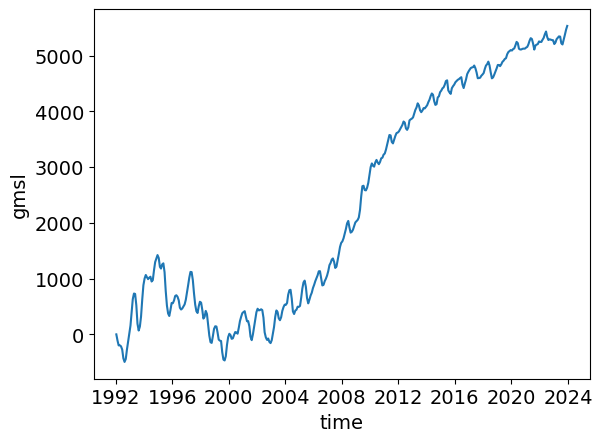

In [248]:
gmsl_Gt.plot();

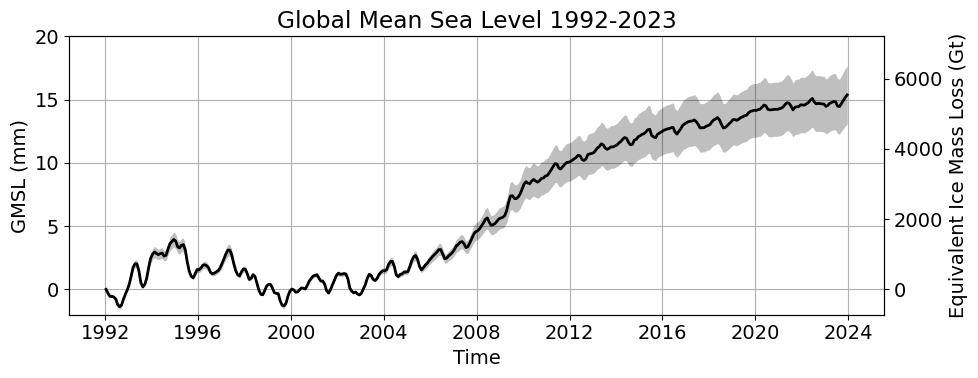

In [274]:
plt.rcParams['font.size'] = 14

fig, ax = plt.subplots(figsize=(10,4))

# Primary axis (mm)
ax.plot(
    gmsl_ds.time,
    gmsl_ds.gmsl,
    color="k",
    linewidth=1,
    label="GMSL"
)

ax.set_xlabel("Time")
ax.set_ylabel("GMSL (mm)", color="k")
ax.tick_params(axis='y', labelcolor="k")
ax.grid(True)

# Secondary axis (Gt)
ax2 = ax.twinx()

gmsl_gt = gmsl_ds.gmsl * 360
unc_gt = gmsl_uncertainty

ax2.plot(
    gmsl_ds.time,
    gmsl_gt,
    color="k",
    linewidth=2,
    label="Ice Mass Loss Equivalent"
)

# Uncertainty shading (secondary axis)
ax2.fill_between(
    gmsl_ds.time,
    gmsl_gt - unc_gt,
    gmsl_gt + unc_gt,
    color="k",
    alpha=0.25,
    linewidth=0
)

ax2.set_ylabel("Equivalent Ice Mass Loss (Gt)", color="k")
ax2.tick_params(axis='y', labelcolor="k")

ax.set_ylim(-2,20)
ax2.set_ylim(-2*360,20*360)

ax.set_title("Global Mean Sea Level 1992-2023")

fig.tight_layout()
plt.show()

In [234]:
# calculate time and space varying uncertainty
transect_uncertainty = gmsl_uncertainty * transect

In [236]:
transect_uncertainty_june = transect_uncertainty.sel(time=transect_uncertainty.time.dt.month == 6)

In [238]:
# open asl from transect and plot uncertainty
asl_transect = xr.open_dataset("/Users/mzahn/data/SSH/model_ssh/asl_monthly_ar7w_transect.nc").asl_transect

In [240]:
# June monthly means
asl_june = asl_transect.sel(time=asl_transect.time.dt.month == 6)

In [242]:
import matplotlib.colors as mcolors
import matplotlib.cm as cm

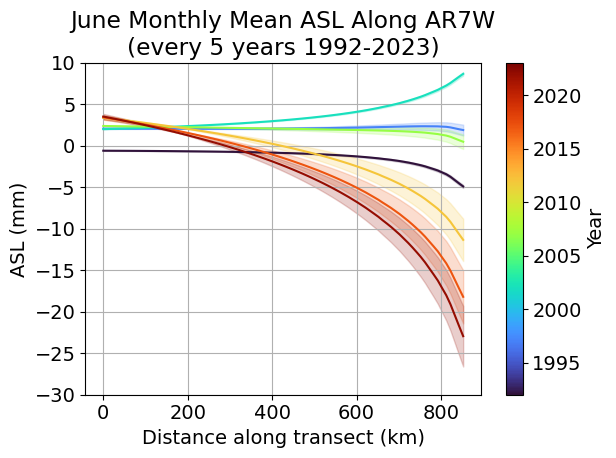

In [244]:
plt.rcParams['font.size'] = 14

# Extract unique years
years = np.unique(asl_june.time.dt.year.values)

# Keep every 5 years
years_to_plot = years[::5]

fig, ax = plt.subplots()

norm = mcolors.Normalize(vmin=years.min(), vmax=years.max())
cmap = cm.turbo

for year in years_to_plot:
    
    # Select June ASL for this year
    asl_year = asl_june.sel(time=asl_june.time.dt.year == year)
    
    # Select corresponding uncertainty
    unc_year = transect_uncertainty_june.sel(time=transect_uncertainty_june.time.dt.year == year)

    y = asl_year.values.flatten()
    unc = unc_year.values.flatten()
    x = asl_transect.distance_km.values

    color = cmap(norm(year))

    # Plot line
    ax.plot(
        x,
        y,
        color=color,
        linewidth=1.5
    )

    # Shaded uncertainty
    ax.fill_between(
        x,
        y - unc,
        y + unc,
        color=color,
        alpha=0.2
    )

ax.set_xlabel("Distance along transect (km)")
ax.set_ylabel("ASL (mm)")
ax.set_title("June Monthly Mean ASL Along AR7W\n(every 5 years 1992-2023)")
ax.grid(True)

ax.set_ylim(-30,10)

# Colorbar
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Year")

fig.tight_layout()
plt.show()